# 01 — Exploration et préparation des données

Ce notebook est la **base de tout le projet**. Avant d'entraîner un modèle, il faut :
1. Comprendre ce que contiennent nos données
2. Les préparer correctement (format, dimensions, normalisation)
3. Créer des DataLoaders prêts à être utilisés par nos modèles

---

> **Note Kaggle / Local**  
> Ce notebook fonctionne dans les deux environnements. Une variable `KAGGLE` en début de notebook permet de basculer automatiquement les chemins des datasets.

## Section 1 — Environnement

### Pourquoi vérifier l'environnement ?

PyTorch peut utiliser trois backends de calcul :
- **CPU** : lent, mais disponible partout
- **CUDA** : GPU NVIDIA, le plus rapide (Kaggle/Colab)
- **MPS** : GPU Apple Silicon (ton Mac M1/M2), plus rapide que CPU

En définissant un `device` dès le début, tout le code ultérieur sera portable — il fonctionnera sur ton Mac ET sur Kaggle sans modification.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")

# --- Sélection automatique du device ---
# torch.cuda.is_available() retourne True si un GPU NVIDIA est détecté
# torch.backends.mps.is_available() retourne True sur Apple Silicon
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"\nDevice utilisé      : {device}")

PyTorch version     : 2.11.0
Torchvision version : 0.26.0

Device utilisé      : mps


In [2]:
# --- Configuration globale ---

# Mets KAGGLE = True quand tu exécutes sur Kaggle
KAGGLE = False

# En local, on charge un sous-ensemble pour aller vite
# Sur Kaggle, on charge tout
DEBUG_SUBSET = 500  # nombre d'images à charger en mode local

if KAGGLE:
    DATA_DIR = "/kaggle/input"
else:
    DATA_DIR = "../data"
    os.makedirs(DATA_DIR, exist_ok=True)

print(f"Mode Kaggle : {KAGGLE}")
print(f"Dossier data : {DATA_DIR}")

Mode Kaggle : False
Dossier data : ../data


## Section 2 — CIFAR-10

### Qu'est-ce que CIFAR-10 ?

CIFAR-10 est un dataset standard en deep learning, créé par le Canadian Institute For Advanced Research.

- **60 000 images** au total
- **32×32 pixels**, couleur (3 canaux RGB)
- **10 classes** équilibrées : avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau, camion
- Split standard : 50 000 entraînement / 10 000 test

C'est un excellent dataset pour débuter car il est léger et bien équilibré.

### La normalisation

Les pixels bruts sont des entiers entre **0 et 255**. On les normalise en flottants entre **-1 et 1**.

**Pourquoi -1 à 1 pour les GANs ?**  
Le générateur utilise une fonction d'activation `tanh` en sortie, qui produit des valeurs dans [-1, 1]. Pour que les images réelles et générées soient comparables, les vraies images doivent être dans le même espace.

La formule appliquée par `transforms.Normalize((0.5,), (0.5,))` est :  
`pixel_normalisé = (pixel / 255 - 0.5) / 0.5`  
Ce qui donne bien une valeur dans [-1, 1].

In [3]:
# --- Transformation des images CIFAR-10 ---

# transforms.Compose() permet de chaîner plusieurs transformations
# Elles seront appliquées dans l'ordre à chaque image chargée
cifar10_transform = transforms.Compose([
    # ToTensor() convertit une image PIL (H x W x C, valeurs 0-255)
    # en tenseur PyTorch (C x H x W, valeurs 0.0-1.0)
    # Le changement d'ordre des dimensions est important :
    # PyTorch travaille en (Channels, Height, Width) et non (H, W, C)
    transforms.ToTensor(),

    # Normalize(mean, std) applique : (x - mean) / std par canal
    # Avec mean=0.5 et std=0.5 : (x - 0.5) / 0.5 → valeurs dans [-1, 1]
    # On fournit 3 valeurs car il y a 3 canaux (R, G, B)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- Chargement du dataset ---
# download=True télécharge automatiquement si absent
# train=True charge le split d'entraînement (50 000 images)
cifar10_full = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=cifar10_transform
)

print(f"Taille du dataset CIFAR-10 complet : {len(cifar10_full)} images")
print(f"Dimension d'une image              : {cifar10_full[0][0].shape}")
print(f"  → (canaux, hauteur, largeur) = (3, 32, 32)")

Taille du dataset CIFAR-10 complet : 50000 images
Dimension d'une image              : torch.Size([3, 32, 32])
  → (canaux, hauteur, largeur) = (3, 32, 32)


/Users/Apple/Desktop/Projets/Deep learning/venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
# --- Sous-ensemble pour le mode local ---

# Subset() crée une vue partielle du dataset sans copier les données
# range(DEBUG_SUBSET) sélectionne les 500 premières images
if not KAGGLE:
    cifar10_dataset = Subset(cifar10_full, range(DEBUG_SUBSET))
    print(f"Mode local : {len(cifar10_dataset)} images chargées (subset de debug)")
else:
    cifar10_dataset = cifar10_full
    print(f"Mode Kaggle : {len(cifar10_dataset)} images chargées (dataset complet)")

Mode local : 500 images chargées (subset de debug)


### DataLoader — qu'est-ce que c'est ?

Un **DataLoader** est un objet qui va alimenter ton modèle en données pendant l'entraînement.

Il gère automatiquement :
- Le **découpage en batches** (lots) : on ne passe jamais toutes les images d'un coup, c'est trop lourd pour la mémoire
- Le **mélange (shuffle)** : à chaque epoch, les images sont présentées dans un ordre différent pour éviter que le modèle mémorise l'ordre
- Le **chargement parallèle** : `num_workers` définit le nombre de processus qui préparent les données en avance pendant que le GPU travaille

**Qu'est-ce qu'un batch ?**  
Au lieu de passer une image à la fois, on en passe plusieurs ensemble (ici 64). Cela :
- Stabilise l'entraînement (gradient calculé sur plus d'exemples)
- Exploite mieux le parallélisme du GPU

In [5]:
# --- Création du DataLoader CIFAR-10 ---

BATCH_SIZE = 64  # nombre d'images par batch — standard pour les GANs

cifar10_loader = DataLoader(
    cifar10_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # mélange à chaque epoch
    num_workers=2,      # 2 processus de chargement en parallèle
    pin_memory=True     # optimisation mémoire pour le transfert CPU → GPU
)

print(f"Batch size        : {BATCH_SIZE}")
print(f"Nombre de batches : {len(cifar10_loader)}")
print(f"  → {len(cifar10_dataset)} images / {BATCH_SIZE} = {len(cifar10_loader)} batches par epoch")

Batch size        : 64
Nombre de batches : 8
  → 500 images / 64 = 8 batches par epoch


### Visualisation des images CIFAR-10

Avant de confier les données à un modèle, **toujours visualiser** ce qu'on lui donne. C'est la façon la plus rapide de détecter un bug dans le preprocessing.

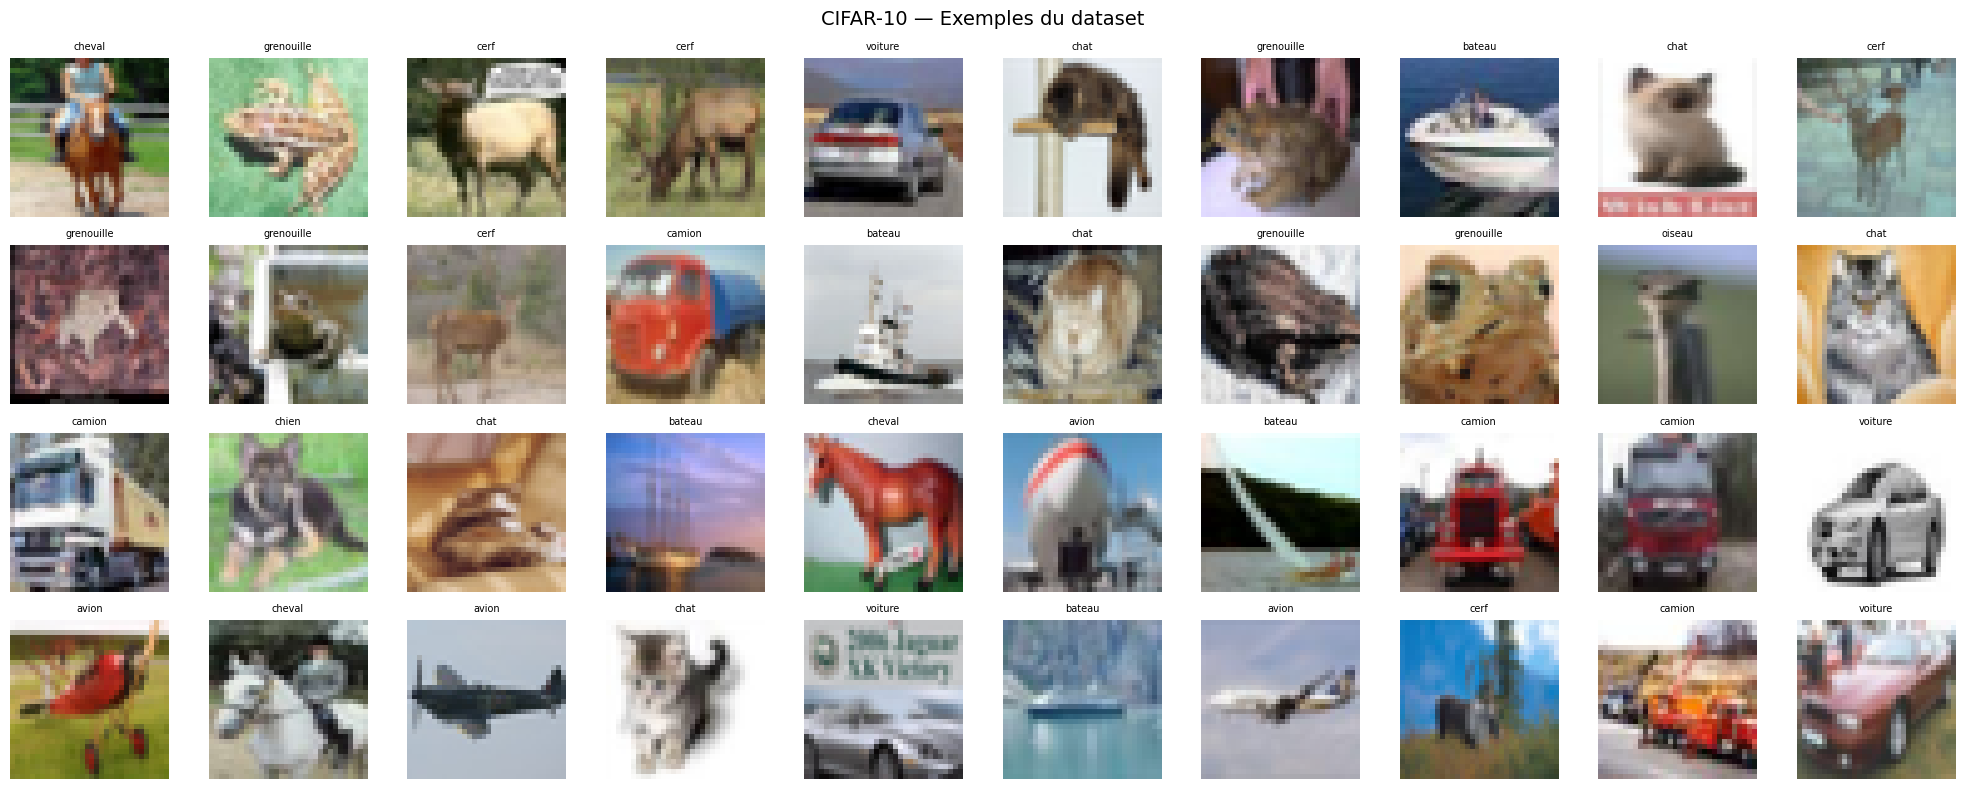

In [6]:
# Noms des 10 classes dans l'ordre de leurs indices (0 à 9)
CIFAR10_CLASSES = [
    'avion', 'voiture', 'oiseau', 'chat', 'cerf',
    'chien', 'grenouille', 'cheval', 'bateau', 'camion'
]

def denormalize(tensor):
    """
    Inverse la normalisation pour afficher l'image correctement.
    La normalisation avait appliqué : (x - 0.5) / 0.5
    L'inverse est donc             : x * 0.5 + 0.5
    Ce qui ramène les valeurs dans [0, 1] lisibles par matplotlib.
    """
    return tensor * 0.5 + 0.5

def show_cifar10_samples(dataset, classes, n=40):
    """
    Affiche n images aléatoires du dataset avec leur label.
    """
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(4, 10, figsize=(20, 8))
    fig.suptitle('CIFAR-10 — Exemples du dataset', fontsize=14)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # permute(1, 2, 0) réordonne de (C, H, W) → (H, W, C)
        # car matplotlib attend (H, W, C)
        img = denormalize(img).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # sécurité pour les valeurs hors [0,1]

        ax = axes[i // 10, i % 10]
        ax.imshow(img)
        ax.set_title(classes[label], fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_cifar10_samples(cifar10_dataset, CIFAR10_CLASSES)

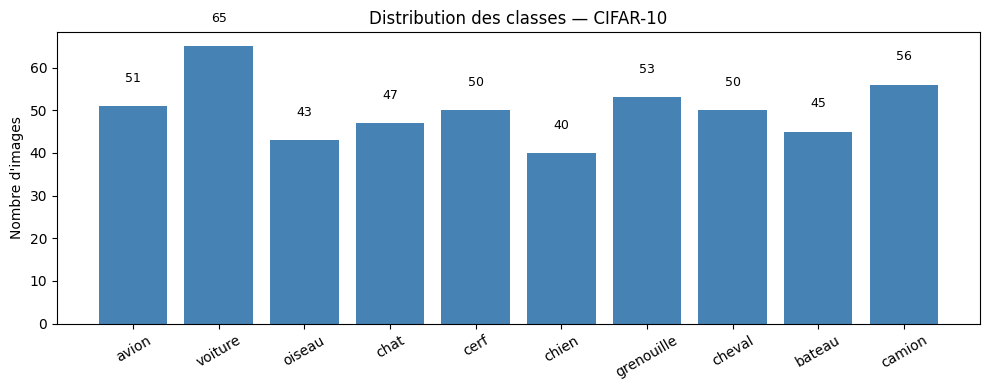

In [7]:
# --- Distribution des classes ---
# Un dataset bien équilibré est important pour un GAN :
# si une classe est sur-représentée, le générateur va y être biaisé

# On récupère les labels de tout le dataset
if not KAGGLE:
    # Pour un Subset, on accède au dataset original via .dataset
    labels = [cifar10_full.targets[i] for i in cifar10_dataset.indices]
else:
    labels = cifar10_dataset.targets

# np.unique retourne les valeurs uniques et leur nombre d'occurrences
unique, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([CIFAR10_CLASSES[i] for i in unique], counts, color='steelblue')
ax.set_title('Distribution des classes — CIFAR-10')
ax.set_ylabel('Nombre d\'images')
plt.xticks(rotation=30)

# Affiche le nombre exact au-dessus de chaque barre
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Section 3 — CelebA

### Qu'est-ce que CelebA ?

CelebA (Large-scale CelebFaces Attributes) est un dataset de visages créé par l'Université chinoise de Hong Kong.

- **202 599 images** de visages de célébrités
- **40 attributs binaires** par image : lunettes, sourire, âge, couleur des cheveux, genre, etc.
- Images en haute résolution (218×178 pixels originaux)

### Pourquoi CelebA est intéressant pour les GANs ?

Les visages humains ont une structure très régulière (deux yeux, un nez, une bouche) ce qui les rend plus faciles à générer que des objets quelconques. C'est pourquoi CelebA est LE dataset de référence pour évaluer la qualité d'un GAN.

### Limitation connue

CelebA est **biaisé** : il sur-représente les visages caucasiens et les célébrités. C'est important à noter dans ton rapport.

In [8]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

# --- Chemin vers le dataset téléchargé via kagglehub ---
# kagglehub télécharge dans un cache global sur la machine
CELEBA_ROOT = "/Users/Apple/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2"
CELEBA_IMGS = os.path.join(CELEBA_ROOT, "img_align_celeba", "img_align_celeba")

# --- Transformation des images CelebA ---
# CelebA a des images de 218×178 pixels
# On recadre le visage puis on redimensionne à 64×64
celeba_transform = transforms.Compose([
    # CenterCrop(140) : découpe un carré de 140×140 au centre
    # → élimine le cou et le fond pour garder uniquement le visage
    transforms.CenterCrop(140),

    # Resize(64) : redimensionne à 64×64
    # → résolution standard pour comparer les 3 architectures
    transforms.Resize(64),

    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- Dataset personnalisé ---
# torchvision.datasets.CelebA attend une structure de fichiers différente
# de ce que kagglehub télécharge. On écrit donc notre propre Dataset.
#
# Un Dataset PyTorch custom doit implémenter deux méthodes obligatoires :
#   __len__     → retourne le nombre total d'images
#   __getitem__ → retourne (image, attributs) pour un index donné

class CelebADataset(Dataset):
    def __init__(self, root_imgs, attr_csv, partition_csv, split='train', transform=None):
        """
        root_imgs     : chemin vers le dossier contenant les .jpg
        attr_csv      : chemin vers list_attr_celeba.csv
        partition_csv : chemin vers list_eval_partition.csv
        split         : 'train' (0), 'valid' (1) ou 'test' (2)
        transform     : transformations à appliquer à chaque image
        """
        self.root_imgs = root_imgs
        self.transform = transform

        # Correspondance nom → numéro de partition dans le CSV
        split_map = {'train': 0, 'valid': 1, 'test': 2}
        split_id  = split_map[split]

        # Lecture des deux fichiers CSV avec pandas
        attrs      = pd.read_csv(attr_csv)       # colonnes : image_id + 40 attributs
        partitions = pd.read_csv(partition_csv)  # colonnes : image_id, partition

        # Fusion sur image_id pour avoir attributs + partition dans un seul dataframe
        merged = attrs.merge(partitions, on='image_id')

        # Filtrage : on garde uniquement les images du split voulu
        merged = merged[merged['partition'] == split_id].reset_index(drop=True)

        # Liste des noms de fichiers images (ex: "000001.jpg")
        self.filenames = merged['image_id'].tolist()

        # Attributs : dans le CSV les valeurs sont -1 et +1
        # On convertit en 0 et 1 avec la formule : (x + 1) / 2
        #   -1 → (-1 + 1) / 2 = 0   (attribut absent)
        #   +1 → (+1 + 1) / 2 = 1   (attribut présent)
        attr_cols = merged.drop(columns=['image_id', 'partition']).values
        self.attrs = torch.tensor((attr_cols + 1) // 2, dtype=torch.float32)

    def __len__(self):
        # PyTorch appelle cette méthode pour connaître la taille du dataset
        return len(self.filenames)

    def __getitem__(self, idx):
        # PyTorch appelle cette méthode à chaque accès dataset[idx]
        img_path = os.path.join(self.root_imgs, self.filenames[idx])
        # PIL.Image.open charge l'image depuis le disque
        # .convert('RGB') garantit 3 canaux même si l'image est en niveaux de gris
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, self.attrs[idx]

print("Transformation CelebA définie :")
print("  218×178 → CenterCrop(140) → 140×140 → Resize(64) → 64×64")
print("  Normalisation vers [-1, 1]")
print()
print("Dataset personnalisé CelebADataset prêt.")

Transformation CelebA définie :
  218×178 → CenterCrop(140) → 140×140 → Resize(64) → 64×64
  Normalisation vers [-1, 1]

Dataset personnalisé CelebADataset prêt.


In [9]:
# --- Chargement de CelebA ---

try:
    celeba_full = CelebADataset(
        root_imgs     = CELEBA_IMGS,
        attr_csv      = os.path.join(CELEBA_ROOT, "list_attr_celeba.csv"),
        partition_csv = os.path.join(CELEBA_ROOT, "list_eval_partition.csv"),
        split         = 'train',
        transform     = celeba_transform
    )
    print(f"CelebA chargé : {len(celeba_full)} images (split train)")
    print(f"Attributs par image : {celeba_full.attrs.shape[1]}")

    # Vérification rapide : afficher le nom et les attributs de la première image
    img0, attr0 = celeba_full[0]
    print(f"\nPremière image : {celeba_full.filenames[0]}")
    print(f"Shape image    : {img0.shape}")
    print(f"Shape attributs: {attr0.shape}")

except Exception as e:
    print(f"Erreur : {e}")
    celeba_full = None

CelebA chargé : 162770 images (split train)
Attributs par image : 40

Première image : 000001.jpg
Shape image    : torch.Size([3, 64, 64])
Shape attributs: torch.Size([40])


In [10]:
# --- Sous-ensemble local + DataLoader CelebA ---

if celeba_full is not None:

    if not KAGGLE:
        celeba_dataset = Subset(celeba_full, range(DEBUG_SUBSET))
        print(f"Mode local : {len(celeba_dataset)} images (subset de debug)")
    else:
        celeba_dataset = celeba_full
        print(f"Mode Kaggle : {len(celeba_dataset)} images (dataset complet)")

    celeba_loader = DataLoader(
        celeba_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        # num_workers=0 en local car la classe CelebADataset est définie dans le notebook
        # Python multiprocessing ne peut pas la sérialiser (pickle) pour les workers parallèles
        # Sur Kaggle avec un fichier .py importable, on pourra remettre num_workers=2
        num_workers=0,
        pin_memory=True
    )

    print(f"Nombre de batches : {len(celeba_loader)}")

Mode local : 500 images (subset de debug)
Nombre de batches : 8


### Les 40 attributs de CelebA

Chaque image est accompagnée d'un vecteur de 40 valeurs binaires (0 ou 1).  
Ces attributs permettront plus tard de **contrôler** la génération : générer un visage souriant, avec des lunettes, etc.

In [11]:
# --- Noms des 40 attributs CelebA ---

CELEBA_ATTRS = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
    'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
    'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
    'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
    'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
    'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks',
    'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
    'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young'
]

print(f"Nombre d'attributs : {len(CELEBA_ATTRS)}")
print("\nQuelques attributs intéressants pour la génération contrôlée :")
attrs_interessants = ['Smiling', 'Eyeglasses', 'Young', 'Male', 'Blond_Hair', 'Bald']
for attr in attrs_interessants:
    print(f"  - {attr} (index {CELEBA_ATTRS.index(attr)})")

Nombre d'attributs : 40

Quelques attributs intéressants pour la génération contrôlée :
  - Smiling (index 31)
  - Eyeglasses (index 15)
  - Young (index 39)
  - Male (index 20)
  - Blond_Hair (index 9)
  - Bald (index 4)


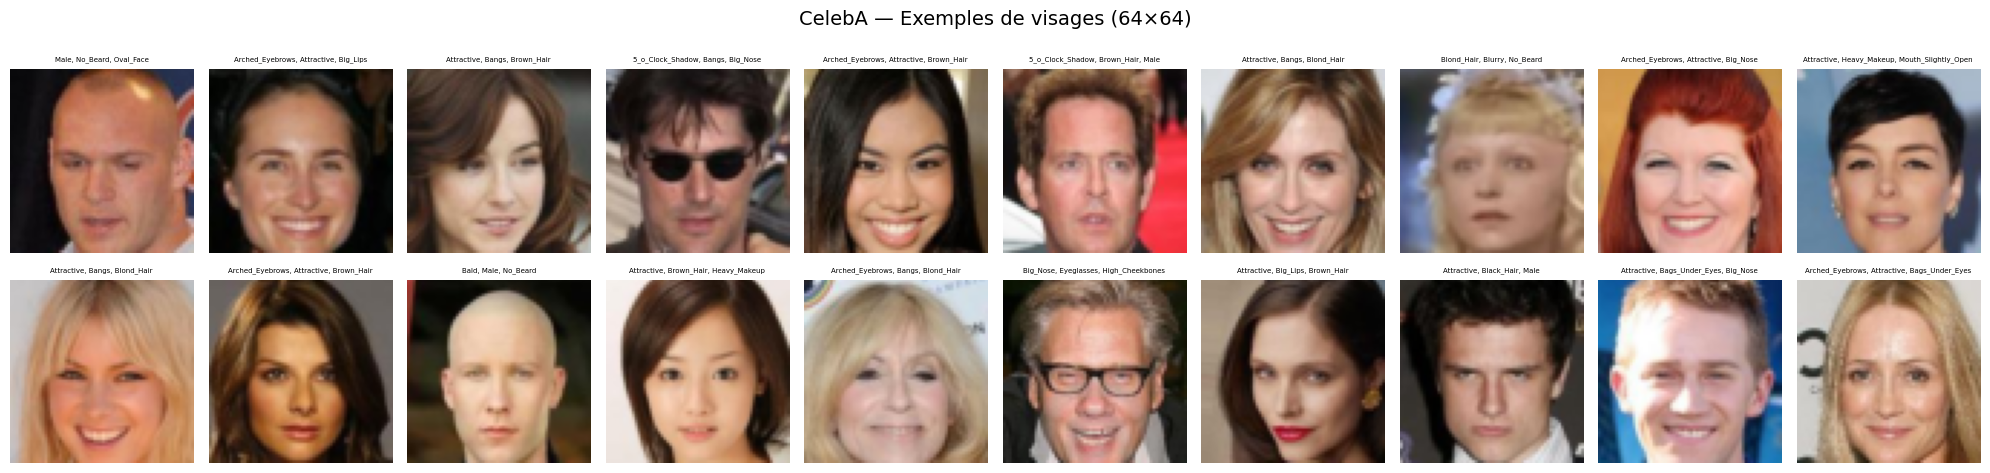

In [12]:
# --- Visualisation CelebA ---

if celeba_full is not None:

    def show_celeba_samples(dataset, attrs, n=20):
        """
        Affiche n visages avec leurs attributs positifs (valeur = 1).
        """
        indices = np.random.choice(len(dataset), n, replace=False)
        fig, axes = plt.subplots(2, 10, figsize=(20, 5))
        fig.suptitle('CelebA — Exemples de visages (64×64)', fontsize=14)

        for i, idx in enumerate(indices):
            img, attr_vector = dataset[idx]
            img = denormalize(img).permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            # Récupère les noms des attributs présents (valeur 1)
            attr_names = [attrs[j] for j in range(len(attrs)) if attr_vector[j] == 1]
            # Garde seulement les 3 premiers pour lisibilité
            attr_str = ', '.join(attr_names[:3])

            ax = axes[i // 10, i % 10]
            ax.imshow(img)
            ax.set_title(attr_str, fontsize=5)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    show_celeba_samples(celeba_dataset, CELEBA_ATTRS)

## Section 4 — Vérification du preprocessing

### Pourquoi cette étape est critique

Un GAN apprend à imiter la distribution des données réelles. Si tes données sont mal normalisées ou mal dimensionnées, le modèle apprendra à imiter quelque chose d'incorrect — et tu auras de mauvais résultats sans comprendre pourquoi.

On vérifie ici que :
1. Les dimensions sont correctes
2. Les valeurs sont bien dans [-1, 1]
3. Un batch sort bien du DataLoader dans le bon format

In [13]:
# --- Vérification CIFAR-10 ---

# On récupère un batch depuis le DataLoader
# iter() crée un itérateur, next() récupère le premier élément
batch_images, batch_labels = next(iter(cifar10_loader))

print("=== Vérification CIFAR-10 ===")
print(f"Shape du batch    : {batch_images.shape}")
print(f"  → (batch_size, canaux, hauteur, largeur) = ({BATCH_SIZE}, 3, 32, 32)")
print(f"Valeur min        : {batch_images.min():.4f}  (attendu : ≈ -1.0)")
print(f"Valeur max        : {batch_images.max():.4f}  (attendu : ≈ +1.0)")
print(f"Type de données   : {batch_images.dtype}  (attendu : float32)")
print(f"Labels shape      : {batch_labels.shape}")
print(f"Labels (premiers) : {batch_labels[:8].tolist()}")

/Users/Apple/Desktop/Projets/Deep learning/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


=== Vérification CIFAR-10 ===
Shape du batch    : torch.Size([64, 3, 32, 32])
  → (batch_size, canaux, hauteur, largeur) = (64, 3, 32, 32)
Valeur min        : -1.0000  (attendu : ≈ -1.0)
Valeur max        : 1.0000  (attendu : ≈ +1.0)
Type de données   : torch.float32  (attendu : float32)
Labels shape      : torch.Size([64])
Labels (premiers) : [2, 8, 2, 9, 0, 1, 9, 1]


In [14]:
# --- Vérification CelebA ---

if celeba_full is not None:
    batch_faces, batch_attrs = next(iter(celeba_loader))

    print("=== Vérification CelebA ===")
    print(f"Shape du batch    : {batch_faces.shape}")
    print(f"  → (batch_size, canaux, hauteur, largeur) = ({BATCH_SIZE}, 3, 64, 64)")
    print(f"Valeur min        : {batch_faces.min():.4f}  (attendu : ≈ -1.0)")
    print(f"Valeur max        : {batch_faces.max():.4f}  (attendu : ≈ +1.0)")
    print(f"Attributs shape   : {batch_attrs.shape}")
    print(f"  → {BATCH_SIZE} images × {len(CELEBA_ATTRS)} attributs")

=== Vérification CelebA ===
Shape du batch    : torch.Size([64, 3, 64, 64])
  → (batch_size, canaux, hauteur, largeur) = (64, 3, 64, 64)
Valeur min        : -1.0000  (attendu : ≈ -1.0)
Valeur max        : 1.0000  (attendu : ≈ +1.0)
Attributs shape   : torch.Size([64, 40])
  → 64 images × 40 attributs


/Users/Apple/Desktop/Projets/Deep learning/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## Section 5 — Récapitulatif

Ce qu'on a préparé dans ce notebook :

In [15]:
print("=" * 50)
print("RÉCAPITULATIF — Données prêtes pour l'entraînement")
print("=" * 50)
print()
print("CIFAR-10")
print(f"  Images   : {len(cifar10_dataset)}")
print(f"  Format   : (3, 32, 32) — valeurs dans [-1, 1]")
print(f"  Batches  : {len(cifar10_loader)} × {BATCH_SIZE} images")
print()

if celeba_full is not None:
    print("CelebA")
    print(f"  Images   : {len(celeba_dataset)}")
    print(f"  Format   : (3, 64, 64) — valeurs dans [-1, 1]")
    print(f"  Batches  : {len(celeba_loader)} × {BATCH_SIZE} images")
    print(f"  Attributs: {len(CELEBA_ATTRS)} par image")

print()
print(f"Device cible : {device}")
print()
print("Prochain notebook : 02_dcgan_training.ipynb")

RÉCAPITULATIF — Données prêtes pour l'entraînement

CIFAR-10
  Images   : 500
  Format   : (3, 32, 32) — valeurs dans [-1, 1]
  Batches  : 8 × 64 images

CelebA
  Images   : 500
  Format   : (3, 64, 64) — valeurs dans [-1, 1]
  Batches  : 8 × 64 images
  Attributs: 40 par image

Device cible : mps

Prochain notebook : 02_dcgan_training.ipynb


---

## Ce qu'on a appris dans ce notebook

| Concept | Explication |
|---|---|
| `device` | Abstraction PyTorch qui pointe vers CPU, GPU CUDA ou GPU MPS |
| `transforms.Compose` | Pipeline de transformations appliquées à chaque image |
| Normalisation [-1, 1] | Nécessaire pour les GANs car le générateur utilise `tanh` en sortie |
| `DataLoader` | Gère les batches, le shuffle et le chargement parallèle |
| `Subset` | Permet de travailler sur une fraction du dataset en local |
| `CenterCrop` | Découpe le centre pour éliminer les bords non informatifs |
| Format `(C, H, W)` | Convention PyTorch : Channels avant Height et Width |